---

**Probabilistic Artificial Intelligence**

---


**Contents**
--------
1. What is Machine learning
2. Different ways of learning from data
3. Implementation of a Naive Bayes Classifier


### 1. Setting up the enviroment
Loading common Libraries.


In [1]:
# pip install jupyter
from IPython.display import Image
import numpy as np
import pandas as pd

### 2. Loading and testing the Iris dataset

We can take an example of predicting the type of flower based on the sepal length and width of the flower. Let's say we have some data (discretized iris data set on sepal length and width). The dataset looks something like this:

In [2]:
from sklearn.datasets import load_iris

iris = load_iris()
mini_iris = np.round(iris.data[:, :2]).astype(int)
data = pd.DataFrame(mini_iris, columns=['length', 'width'])
data['type'] = iris.target

#Shuffle data
data = data.iloc[np.random.permutation(len(data))]
data

,length,width,type
64,6,3,1
34,5,3,0
56,6,3,1
65,7,3,1
40,5,4,0
...,...,...,...
7,5,3,0
84,5,3,1
49,5,3,0
85,6,3,1


### 2. Different ways of learning from data

Now let's say we want to predict the type of flower for a new given data point. There are multiple ways to solve this problem. We will consider these two ways in some detail:  

1. We could find a function which can directly map an input value to it's class label. 
2. We can find the probability distributions over the variables and then use this distribution to answer queries about the new data point.

There are a lot of algorithms for finding a mapping function. For example linear regression tries to find a linear equation which explains the data. Support vector machine tries to find a plane which separates the data points. Decision Tree tries to find a set of simple greater than and less than equations to classify the data. Let's try to apply Decision Tree on this data set.

We can plot the data and it looks something like this:

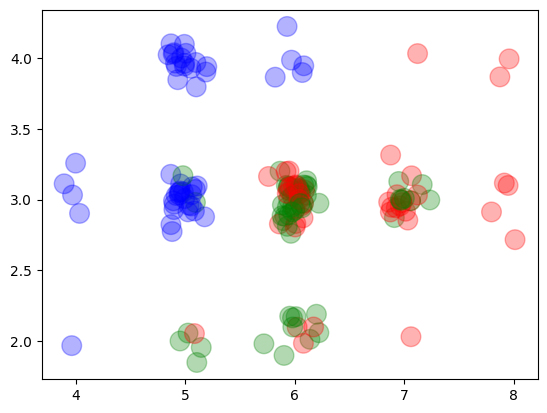

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# Adding a little bit of noise so that it's easier to visualize
data_with_noise = data.iloc[:, :2] + np.random.normal(loc=0, scale=0.1, size=(150, 2))
plt.scatter(data_with_noise.length, data_with_noise.width, c=[ "bgr"[k] for k in data.iloc[:,2] ], s=200, alpha=0.3)

In the plot we can easily see that the blue points are concentrated on the top-left corner, green ones in bottom left and red ones in top right. 

Now let's try to train a Decision Tree on this data.

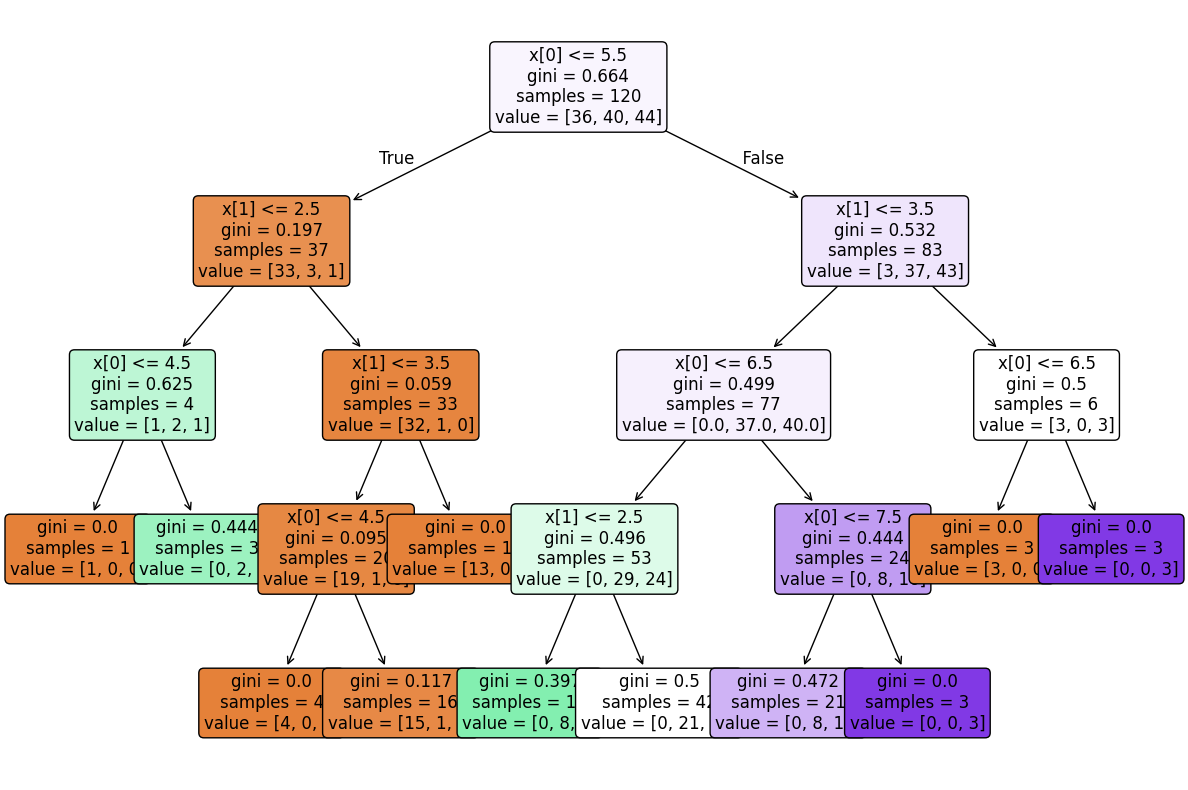

Predictions:


array([1, 1, 2, 0, 1, 0, 0, 2, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0,
       0, 2, 0, 1, 0, 1, 0, 1])

In [4]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data[['length', 'width']].values, data.type.values, test_size=0.2)

classifier = DecisionTreeClassifier(max_depth=4)
classifier.fit(X_train, y_train)

plt.figure(figsize=(15, 10))
plot_tree(classifier, 
          filled=True, 
          rounded=True, 
          fontsize=12)
plt.show()

print('Predictions:')
classifier.predict(X_test)

In [5]:
classifier.score(X_test, y_test)

0.8666666666666667

So, in this case we got a classification accuracy of 86 %.

Now moving on to our second approach using a probabilistic model.
The most obvious way to do this classification task would be to compute a Joint Probability Distribution over all these variables and then marginalize and reduce over these according to our new data point to get the probabilities of classes.

In [6]:
X_train, X_test = data[:120], data[120:]

In [7]:
X_train

,length,width,type
64,6,3,1
34,5,3,0
56,6,3,1
65,7,3,1
40,5,4,0
...,...,...,...
130,7,3,2
75,7,3,1
71,6,3,1
59,5,3,1


In [8]:
# Computing the joint probability distribution over the training data
joint_prob = X_train.groupby(['length', 'width', 'type']).size() / 120
joint_prob

length  width  type
4       2      0       0.008333
        3      0       0.025000
5       2      1       0.025000
        3      0       0.116667
               1       0.008333
        4      0       0.116667
6       2      1       0.075000
               2       0.025000
        3      1       0.183333
               2       0.158333
        4      0       0.033333
7       2      2       0.008333
        3      1       0.050000
               2       0.108333
        4      2       0.008333
8       3      2       0.033333
        4      2       0.016667
dtype: float64

In [9]:
# Marginalizing over the length and width variables to get the probability of each class
p_type = joint_prob.groupby(level='type').sum()
p_type

type
0    0.300000
1    0.341667
2    0.358333
dtype: float64

In [ ]:
# Compute the distribution of type, conditioned on length = 5

type
0    0.200000
1    0.050000
2    0.008333
dtype: float64
type
0    0.774194
1    0.193548
2    0.032258
dtype: float64


In [ ]:
# Try conditioning on two variables, length=5 and width=3

type
0    0.933333
1    0.066667
dtype: float64

In [22]:
# Predicting values using the joint probability distribution

# Selecting just the feature variables.
X_test_features = X_test.iloc[:, :2].values
X_test_actual_results = X_test.iloc[:, 2].values

predicted_values = []
for i in X_test_features:
    predicted_values.append(joint_prob[i[0], i[1]].idxmax())
    
predicted_values = np.array(predicted_values)
predicted_values

array([2, 0, 0, 2, 0, 0, 2, 0, 0, 2, 2, 2, 2, 0, 0, 2, 0, 0, 0, 0, 1, 2,
       0, 0, 2, 2, 0, 0, 1, 2])

In [23]:
# Comparing results with the actual data.
predicted_values == X_test_actual_results

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
       False, False, False, False,  True,  True,  True,  True,  True,
        True,  True,  True, False,  True,  True, False, False,  True,
        True,  True,  True])

In [24]:
score = (predicted_values == X_test_actual_results).sum() / 30
print(score)

0.7666666666666667


### 4. Test the following datasets %TODO%

- Titanic Survival Dataset;
- Soybean Disease; More info: https://archive-beta.ics.uci.edu/dataset/91/soybean+small


### 5. Playing with Bayes Rule

In [3]:
P_T_given_D1 = 0.99   # P(T=1|D=1) sensitivity
P_T_given_D0 = 1 - 0.99   # P(T=1|D=0) = 1 - P(T=0|D=0)
P_D1 = 0.0001         # P(D=1) prior (disease rare 0.01%)
P_D0 = 1 - P_D1       # P(D=0)

# P(T=1) by sum rule
P_T1 = P_T_given_D1 * P_D1 + P_T_given_D0 * P_D0

# Bayes: P(D=1|T=1)
P_D1_given_T1 = (P_T_given_D1 * P_D1) / P_T1

### 6. Implement a Naive Bayes classifier from scratch

The next challenge is to implement the Naive Bayes algorithm from scratch in Python (without libraries).





In [ ]:
from sklearn.datasets import load_iris
from math import sqrt, exp, pi
from pprint import pprint

# load Iris dataset
iris = load_iris()
dataset = [list(iris.data[i]) + [int(iris.target[i])] for i in range(len(iris.target))]

# splitting dataset by class values, returns a dictionary
def separate_by_class(dataset):
    separated = dict()
    for i in range(len(dataset)):
        vector = dataset[i]
        class_value = vector[-1]
        if (class_value not in separated):
            separated[class_value] = list()
        separated[class_value].append(vector)
    return separated

# compute the mean of a list of numbers
def mean(numbers):
    return sum(numbers) / float(len(numbers))

# compute the standard deviation of a list of numbers
def stdev(numbers):
    avg = mean(numbers)
    variance = sum([(x - avg)**2 for x in numbers]) / float(len(numbers) - 1)
    return sqrt(variance)

# compute the mean, stdev and count for each column in a dataset
def summarize_dataset(dataset):
    summaries = [(mean(column), stdev(column), len(column)) for column in zip(*dataset)]
    del summaries[-1]  # drop class column
    return summaries

# split dataset by class then compute statistics for each row
def summarize_by_class(dataset):
    separated = separate_by_class(dataset)
    summaries = dict()
    for class_value, rows in separated.items():
        summaries[class_value] = summarize_dataset(rows)
    return summaries

# compute the Gaussian probability distribution function for x
def calculate_probability(x, mean, stdev):
    exponent = exp(-((x - mean)**2 / (2 * stdev**2)))
    return (1 / (sqrt(2 * pi) * stdev)) * exponent

# compute the probabilities of predicting each class for a given row
def calculate_class_probabilities(summaries, row):
    # Total number of training examples (sum of per-class counts).
    # summaries[label][0][2] is the count for that class (from summarize_by_class).
    total_rows = sum([summaries[label][0][2] for label in summaries])

    # Dict to hold unnormalized P(class | row) ∝ P(class) × ∏ P(x_i | class).
    probabilities = dict()

    for class_value, class_summaries in summaries.items():
        # Prior P(class): fraction of training examples in this class.
        probabilities[class_value] = summaries[class_value][0][2] / float(total_rows)

        # Naive Bayes: multiply by likelihood of each feature given this class.
        for i in range(len(class_summaries)):
            # Per-feature stats for this class: (mean, stdev, count) for feature i.
            mean_val, stdev_val, _ = class_summaries[i]
            # Avoid division by zero in the Gaussian PDF when a feature has no variance.
            if stdev_val == 0:
                stdev_val = 1e-10
            # Multiply by P(row[i] | class) under the Gaussian model.
            probabilities[class_value] *= calculate_probability(row[i], mean_val, stdev_val)

    # Return unnormalized posterior (caller can normalize to get P(class | row)).
    return probabilities

# predict the class for a given row
def predict(summaries, row):
    probabilities = calculate_class_probabilities(summaries, row)
    best_label, best_prob = None, -1
    for class_value, probability in probabilities.items():
        if best_label is None or probability > best_prob:
            best_prob = probability
            best_label = class_value
    return best_label

# Fit model and predict
model = summarize_by_class(dataset)
row = [5.7, 2.9, 4.2, 1.3]  # new record (sepal length, width, petal length, width)
label = predict(model, row)
print('Data=%s, Predicted: %s' % (row, iris.target_names[label]))

Data=[5.7, 2.9, 4.2, 1.3], Predicted: versicolor


In [ ]:
# probabilistic predictions with the Naive Bayes model

row = [5.7, 2.9, 4.2, 1.3]  # example row
probs = calculate_class_probabilities(model, row)

total = sum(probs.values())
probabilities = {iris.target_names[k]: probs[k] / total for k in probs}

print("Probabilistic prediction for", row)
for class_name, p in probabilities.items():
    print("  P(%s) = %.4f" % (class_name, p))
print("Predicted class:", iris.target_names[predict(model, row)])

{0: 3.787400750385335e-77, 1: 0.45601729930563584, 2: 0.0001508798072947009}
Probabilistic prediction for [5.7, 2.9, 4.2, 1.3]
  P(setosa) = 0.0000
  P(versicolor) = 0.9997
  P(virginica) = 0.0003
Predicted class: versicolor


### 7. Using scikit-learn's Naive Bayes

The above uses a variant of Naive Bayes known as Gaussian Naive Bayes.

Gaussian Naive Bayes models the likelihood of each feature given the class with a normal distribution:

$$
P(x_i \mid y) = \frac{1}{\sqrt{2\pi\sigma_y^2}} \exp\left(-\frac{(x_i - \mu_y)^2}{2\sigma_y^2}\right)
$$

where $\mu_y$ is the mean of feature $x_i$ for class $y$ and $\sigma_y^2$ is its variance. The parameters $\mu_y$ and $\sigma_y$ are estimated by maximum likelihood (sample mean and sample variance per class).

Some variants of Naive Bayes are:

- **Gaussian Naive Bayes** — For continuous features (e.g. Iris). Likelihood is a normal distribution per feature per class; parameters are class-conditional mean and variance (as in the model above).

- **Multinomial Naive Bayes** — For discrete counts (e.g. word counts in text). Likelihood is multinomial; parameters are class-conditional counts. Common in text classification (e.g., spam example).

- **Bernoulli Naive Bayes** — For binary features (0/1). One probability per feature per class (word present or absent). Used in binary bag-of-words models.

- **Categorical Naive Bayes** — For categorical features with multiple levels. One discrete distribution per feature per class; parameters are class-conditional category frequencies.

Suggested reading: https://scikit-learn.org/stable/modules/naive_bayes.html

In [ ]:
# sklearn's example for Bernoulli Naive Bayes

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, classification_report

# Load digits dataset 
X, y = load_digits(return_X_y=True)
# binarize pixels for Bernoulli Naive Bayes
X_binary = (X > 0).astype(int)  # Bernoulli: each feature is 0 or 1 (ink present/absent)

X_train, X_test, y_train, y_test = train_test_split(
    X_binary, y, test_size=0.25, random_state=42
)

print(X)
print(X_binary)

bnb = BernoulliNB()
bnb.fit(X_train, y_train)

y_pred = bnb.predict(X_test)
print("Accuracy: %.3f" % accuracy_score(y_test, y_pred))
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=[str(i) for i in range(10)]))

# Example prediction for one test sample
idx = 0
probs = bnb.predict_proba(X_test[idx:idx+1])[0]
print("\nExample: first test image")
print("Predicted class:", y_pred[idx])
print("Class probabilities:", dict(zip(range(10), probs.round(4))))

[[ 0.  0.  5. ...  0.  0.  0.]
 [ 0.  0.  0. ... 10.  0.  0.]
 [ 0.  0.  0. ... 16.  9.  0.]
 ...
 [ 0.  0.  1. ...  6.  0.  0.]
 [ 0.  0.  2. ... 12.  0.  0.]
 [ 0.  0. 10. ... 12.  1.  0.]]
[[0 0 1 ... 0 0 0]
 [0 0 0 ... 1 0 0]
 [0 0 0 ... 1 1 0]
 ...
 [0 0 1 ... 1 0 0]
 [0 0 1 ... 1 0 0]
 [0 0 1 ... 1 1 0]]
Accuracy: 0.867

Classification report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.79      0.62      0.70        37
           2       0.79      0.87      0.82        38
           3       0.85      0.85      0.85        46
           4       0.91      0.96      0.94        55
           5       0.98      0.80      0.88        59
           6       0.96      0.98      0.97        45
           7       0.89      1.00      0.94        41
           8       0.74      0.84      0.79        38
           9       0.74      0.77      0.76        48

    accuracy                           0.87       45

### 8. Test the following datasets %TODO%

- Titanic Survival Dataset;
- Soybean Disease;
